# PicoCal — Data understanding & PyTorch tokens

## Setup

In [1]:
from pathlib import Path
import collections
import numpy as np
import awkward as ak
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader


plt.rcParams.update({"figure.figsize": (7, 5), "axes.grid": True, "font.size": 12})

repo = Path.cwd().resolve()
if repo.name == "notebooks":
    repo = repo.parent
root_files = sorted((repo / "data" / "full").glob("matched_*.root"))
INPUT_FILE = root_files[0]
TREE_NAME = "clusters_matched"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
INPUT_FILE.name, len(root_files), str(DEVICE)

('matched_1001_1010.root', 100, 'cpu')

## Understand the data — feature inventory

In [2]:
with uproot.open(INPUT_FILE) as f:
    tree = f[TREE_NAME]
    n_entries = tree.num_entries
    arrays = tree.arrays(library="ak")

rows = []
for name in arrays.fields:
    arr = arrays[name]
    if arr.ndim > 1:
        n = ak.to_numpy(ak.num(arr, axis=1))
        rows.append({"branch": name, "kind": "jagged", "min": int(n.min()),
                     "median": int(np.median(n)), "max": int(n.max()), "note": "per cell"})
    else:
        v = ak.to_numpy(arr).astype(float)
        v = v[np.isfinite(v)]
        rows.append({"branch": name, "kind": "scalar", "min": round(float(v.min()), 3),
                     "median": round(float(np.median(v)), 3), "max": round(float(v.max()), 3),
                     "note": "per entry"})
pd.DataFrame(rows)

,branch,kind,min,median,max,note
0,sig_flux_entry_x,scalar,-4664.925,-37.272,4642.719,per entry
1,sig_flux_entry_y,scalar,-2898.715,52.518,3057.126,per entry
2,sig_flux_entry_z,scalar,12619.990,12619.990,12619.990,per entry
3,sig_flux_px,scalar,-4810.399,-0.425,4717.028,per entry
4,sig_flux_py,scalar,-4833.916,13.985,4854.786,per entry
5,sig_flux_pz,scalar,934.375,4022.489,203003.354,per entry
6,sig_flux_prod_vertex_x,scalar,-3677.943,0.000,3138.295,per entry
7,sig_flux_prod_vertex_y,scalar,-2674.762,0.000,2626.323,per entry
8,sig_flux_prod_vertex_z,scalar,0.000,11994.501,12577.318,per entry
9,sig_flux_timing,scalar,42.104,42.162,47.876,per entry


## Understand the data — four real-vs-instruction facts

In [3]:
ev = ak.to_numpy(arrays["event"])
xc = ak.to_numpy(arrays["x_cluster"]).astype(float)
yc = ak.to_numpy(arrays["y_cluster"]).astype(float)
mult = collections.Counter(zip(ev.tolist(), xc.tolist(), yc.tolist()))
shared = [k for k, c in mult.items() if c > 1]
example_event = shared[0][0] if shared else int(ev[0])
m = ev == example_event
print("event", example_event, "-> entries:", int(m.sum()),
      "| distinct clusters:", len({(round(a, 3), round(b, 3)) for a, b in zip(xc[m], yc[m])}))

eTot = ak.to_numpy(arrays["sig_flux_eTot"]).astype(float)
pz = ak.to_numpy(arrays["sig_flux_pz"]).astype(float)
te = ak.to_numpy(arrays["total_energy"]).astype(float)
print("sig_flux_eTot max:", round(float(eTot.max()), 1), "GeV | sig_flux_pz max:", round(float(pz.max()), 0), "MeV")
print("median total_energy / (eTot*1000):", round(float(np.median(te / (eTot * 1000))), 3))

ncell = ak.to_numpy(ak.num(arrays["energy"], axis=1))
print("cells per cluster: min", int(ncell.min()), "median", int(np.median(ncell)), "max", int(ncell.max()))

present = set(arrays.fields)
print("absent (must derive):", [b for b in ["cell_pitch", "cell_modType", "cell_rel_x", "cell_rel_y", "cell_rel_dr"] if b not in present])

event 4 -> entries: 3 | distinct clusters: 1
sig_flux_eTot max: 203.1 GeV | sig_flux_pz max: 203003.0 MeV
median total_energy / (eTot*1000): 5.332
cells per cluster: min 6 median 132 max 528
absent (must derive): ['cell_pitch', 'cell_modType', 'cell_rel_x', 'cell_rel_y', 'cell_rel_dr']


## Understand the data — event overlap proof

In [4]:
ev_idx = np.flatnonzero(ev == example_event)
cols = ["energy", "cell_x", "cell_y", "cell_energies_front"]
ref = {c: ak.to_numpy(arrays[c][ev_idx[0]]) for c in cols}
same = {c: all(np.array_equal(ref[c], ak.to_numpy(arrays[c][j])) for j in ev_idx) for c in cols}
print("event", example_event, "| tree entries:", ev_idx.tolist())
print("truth photon energies [GeV]:", [round(float(arrays["sig_flux_eTot"][j]), 3) for j in ev_idx])
print("n cells per entry:", [len(ak.to_numpy(arrays["energy"][j])) for j in ev_idx])
print("identical cell arrays across entries:", same)
for j in ev_idx:
    print("  entry", int(j), "energy[:5] =", np.round(ak.to_numpy(arrays["energy"][j])[:5], 1))

event 4 | tree entries: [3, 4, 5]
truth photon energies [GeV]: [1.249, 2.242, 3.734]
n cells per entry: [9, 9, 9]
identical cell arrays across entries: {'energy': True, 'cell_x': True, 'cell_y': True, 'cell_energies_front': True}
  entry 3 energy[:5] = [4639.6   34.3 1630.1  108.3   47.9]
  entry 4 energy[:5] = [4639.6   34.3 1630.1  108.3   47.9]
  entry 5 energy[:5] = [4639.6   34.3 1630.1  108.3   47.9]


## Understand the data — design decisions

In [5]:
pd.DataFrame([
    {"feature": "sig_flux_eTot", "role": "target", "handling": "GeV; as-is or log", "limitation": "instruction says MeV"},
    {"feature": "energy / front / back", "role": "token feature", "handling": "MeV per cell", "limitation": "sampling fluctuations"},
    {"feature": "cell_x / cell_y", "role": "token feature", "handling": "absolute or rel-to-seed", "limitation": "large mm values"},
    {"feature": "cell_pitch / modType", "role": "derived feature", "handling": "neighbour spacing", "limitation": "not stored; approximate"},
    {"feature": "cell_times", "role": "token feature", "handling": "ns; spacetime", "limitation": "noisy at low E"},
    {"feature": "n cells", "role": "sequence length", "handling": "pad + mask", "limitation": "varies 6..528"},
])

,feature,role,handling,limitation
0,sig_flux_eTot,target,GeV; as-is or log,instruction says MeV
1,energy / front / back,token feature,MeV per cell,sampling fluctuations
2,cell_x / cell_y,token feature,absolute or rel-to-seed,large mm values
3,cell_pitch / modType,derived feature,neighbour spacing,not stored; approximate
4,cell_times,token feature,ns; spacetime,noisy at low E
5,n cells,sequence length,pad + mask,varies 6..528


## 1. Branches

In [6]:
with uproot.open(INPUT_FILE) as f:
    print("entries:", f[TREE_NAME].num_entries)
    for k in f[TREE_NAME].keys():
        print("  ", k)

entries: 1791
   sig_flux_entry_x
   sig_flux_entry_y
   sig_flux_entry_z
   sig_flux_px
   sig_flux_py
   sig_flux_pz
   sig_flux_prod_vertex_x
   sig_flux_prod_vertex_y
   sig_flux_prod_vertex_z
   sig_flux_timing
   sig_flux_eTot
   sig_flux_pdgID
   sig_dr_matched
   sig_dxdz_flux
   sig_dydz_flux
   seed_icell_x
   seed_icell_y
   nseed_cell_x
   seed_cell_x
   nseed_cell_y
   seed_cell_y
   nimodx
   imodx
   njmody
   jmody
   nicell
   icell
   ncell_x
   cell_x
   ncell_y
   cell_y
   ncell_energies_front
   cell_energies_front
   ncell_energies_back
   cell_energies_back
   ncell_times_front
   cell_times_front
   ncell_times_back
   cell_times_back
   x_cluster
   y_cluster
   nenergy
   energy
   total_energy_front
   total_energy_back
   total_energy
   event


## 2. Helper functions

In [7]:
n_clusters = len(arrays)

def has_branch(name):
    return name in arrays.fields

def scalar(name):
    return np.asarray(ak.to_numpy(arrays[name])).astype(float)

def safe_divide(num, den):
    num = np.asarray(num, float)
    den = np.asarray(den, float)
    out = np.full_like(num, np.nan)
    ok = np.isfinite(num) & np.isfinite(den) & (den != 0)
    out[ok] = num[ok] / den[ok]
    return out

def get_cluster_cells(i):
    out = {}
    for name in ["cell_x", "cell_y", "cell_energies_front", "cell_energies_back", "energy",
                 "cell_times_front", "cell_times_back", "imodx", "jmody", "icell"]:
        if has_branch(name):
            out[name] = np.asarray(ak.to_numpy(arrays[name][i])).astype(float)
    return out

## 3. Dataset summary

In [8]:
for name in ["sig_flux_eTot", "total_energy", "x_cluster", "y_cluster", "sig_dr_matched"]:
    v = scalar(name)
    print(f"{name:16s} min={np.nanmin(v):10.3f} mean={np.nanmean(v):10.3f} max={np.nanmax(v):10.3f}")

sig_flux_eTot    min=     1.000 mean=    12.869 max=   203.054
total_energy     min=   985.864 mean= 44371.915 max=200589.880
x_cluster        min= -3839.850 mean=   -17.248 max=  3717.950
y_cluster        min= -2986.550 mean=    50.551 max=  3108.450
sig_dr_matched   min=     3.021 mean=    63.477 max=  6687.652


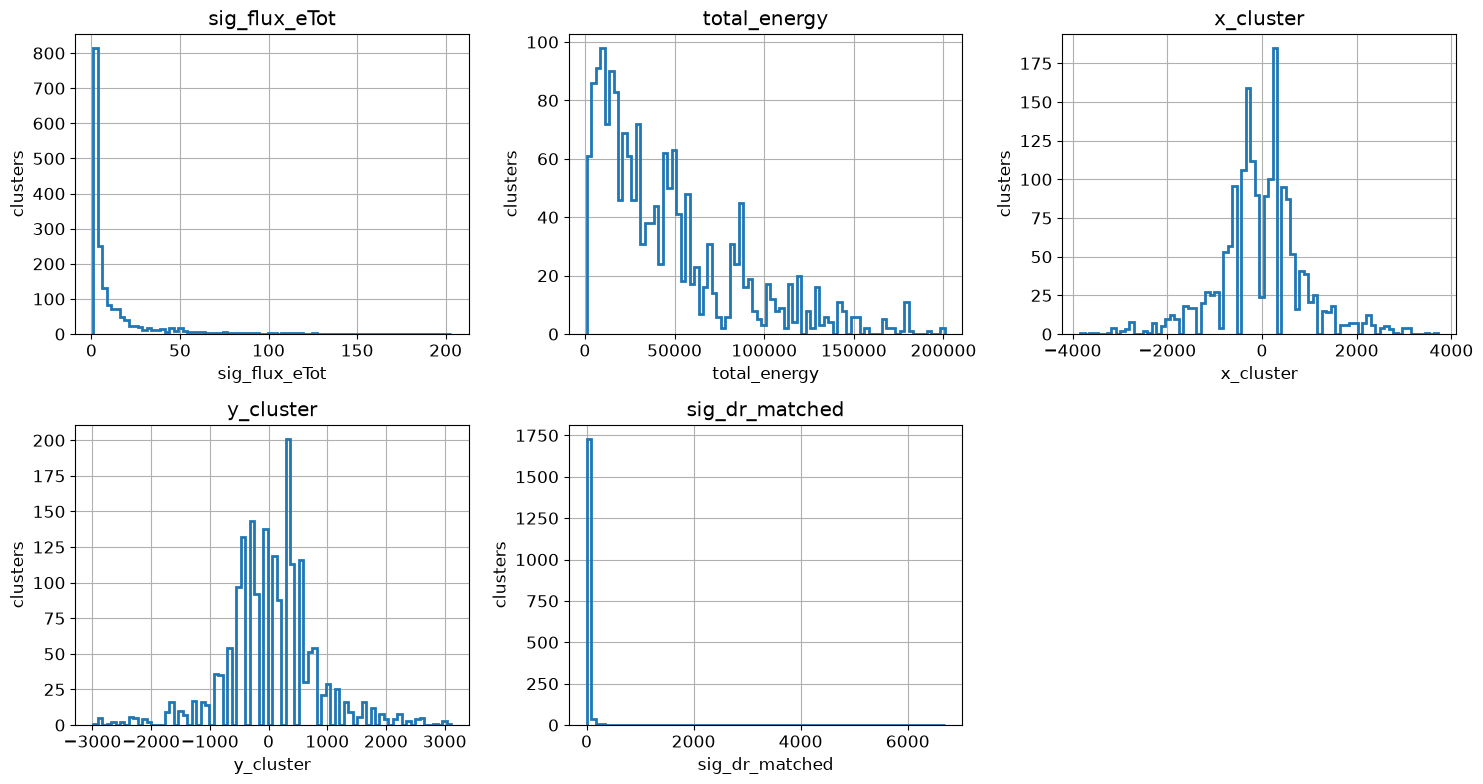

In [9]:
features = ["sig_flux_eTot", "total_energy", "x_cluster", "y_cluster", "sig_dr_matched"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, name in zip(axes, features):
    v = scalar(name)
    v = v[np.isfinite(v)]
    ax.hist(v, bins=80, histtype="step", linewidth=2)
    ax.set_title(name)
    ax.set_xlabel(name)
    ax.set_ylabel("clusters")

for ax in axes[len(features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Cells per cluster

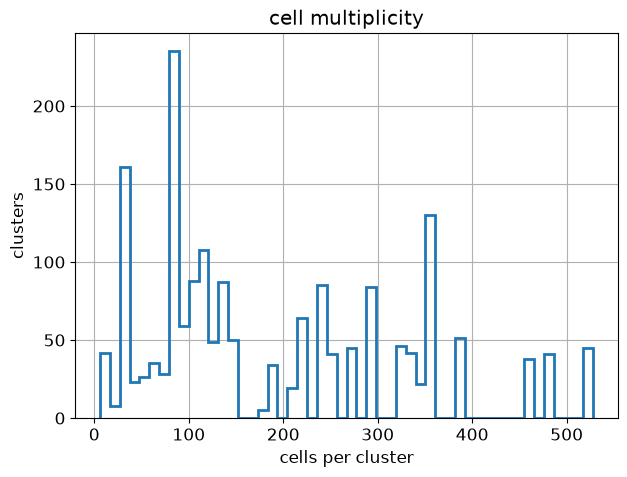

median cells: 132


In [10]:
n_cells = ak.to_numpy(ak.num(arrays["energy"], axis=1))
plt.figure()
plt.hist(n_cells, bins=50, histtype="step", linewidth=2)
plt.xlabel("cells per cluster")
plt.ylabel("clusters")
plt.title("cell multiplicity")
plt.show()
print("median cells:", int(np.median(n_cells)))

## 5. Truth energy

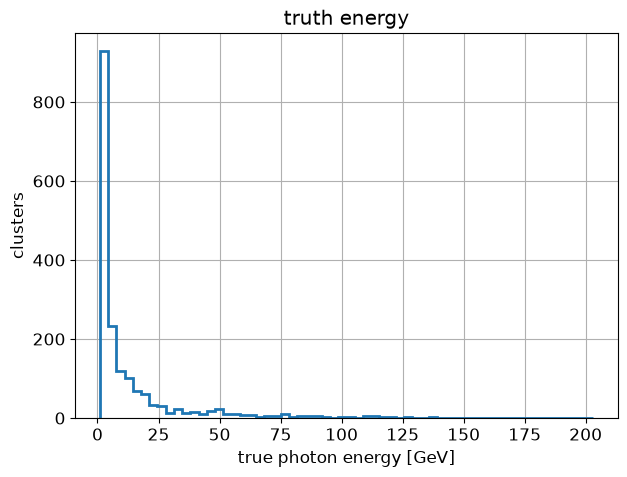

In [11]:
plt.figure()
plt.hist(scalar("sig_flux_eTot"), bins=60, histtype="step", linewidth=2)
plt.xlabel("true photon energy [GeV]")
plt.ylabel("clusters")
plt.title("truth energy")
plt.show()

## 6. Reco vs truth energy

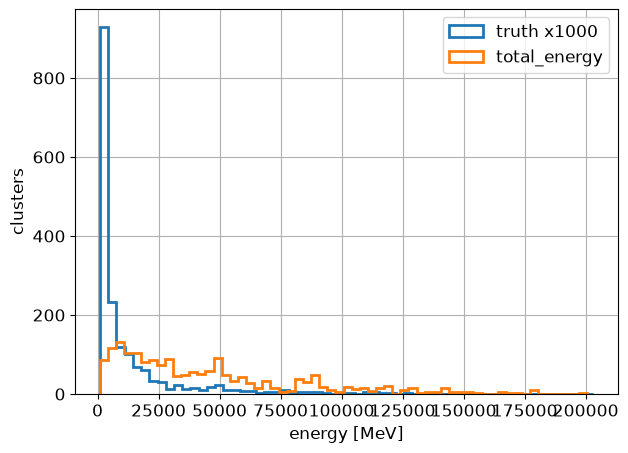

In [12]:
true_mev = scalar("sig_flux_eTot") * 1000
plt.figure()
plt.hist(true_mev, bins=60, histtype="step", linewidth=2, label="truth x1000")
plt.hist(scalar("total_energy"), bins=60, histtype="step", linewidth=2, label="total_energy")
plt.xlabel("energy [MeV]")
plt.ylabel("clusters")
plt.legend()
plt.show()

## 7. Energy response

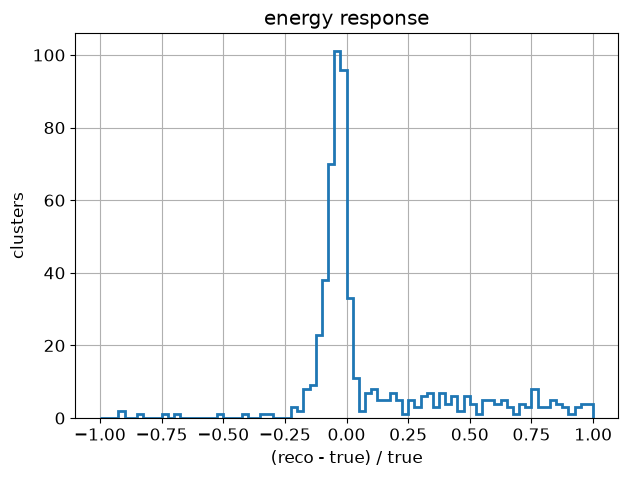

In [13]:
resp = safe_divide(scalar("total_energy") - scalar("sig_flux_eTot") * 1000, scalar("sig_flux_eTot") * 1000)
plt.figure()
plt.hist(resp, bins=80, range=(-1, 1), histtype="step", linewidth=2)
plt.xlabel("(reco - true) / true")
plt.ylabel("clusters")
plt.title("energy response")
plt.show()

## 8. Truth ECAL entry

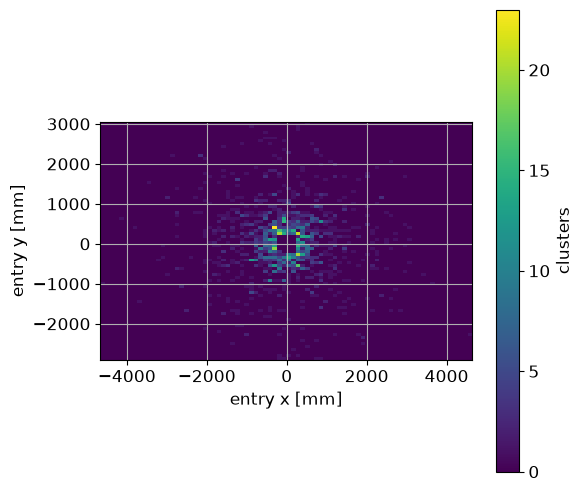

In [14]:
plt.figure(figsize=(6, 6))
plt.hist2d(scalar("sig_flux_entry_x"), scalar("sig_flux_entry_y"), bins=80)
plt.xlabel("entry x [mm]")
plt.ylabel("entry y [mm]")
plt.colorbar(label="clusters")
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

## 9. Cluster vs truth distance

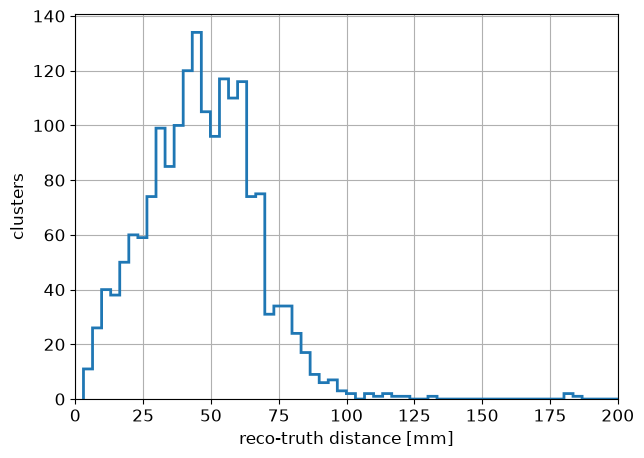

median dr: 46.37 mm


In [15]:
dx = scalar("x_cluster") - scalar("sig_flux_entry_x")
dy = scalar("y_cluster") - scalar("sig_flux_entry_y")
dr = np.sqrt(dx ** 2 + dy ** 2)
plt.figure()
plt.hist(dr, bins=2000, histtype="step", linewidth=2)
plt.xlim(0, 200)
plt.xlabel("reco-truth distance [mm]")
plt.ylabel("clusters")
plt.show()
print("median dr:", round(float(np.nanmedian(dr)), 2), "mm")

## 10. Visualize clusters

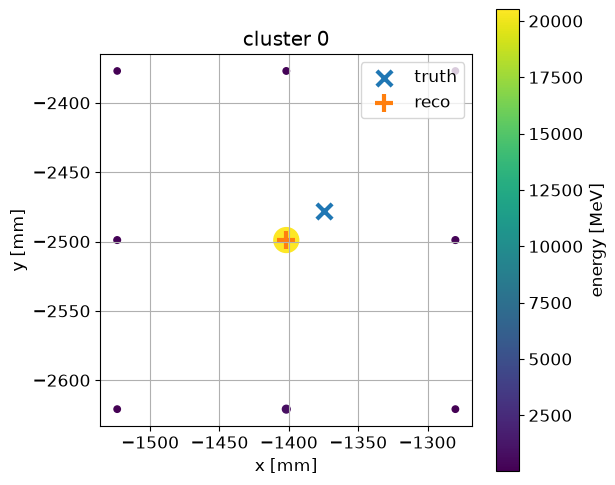

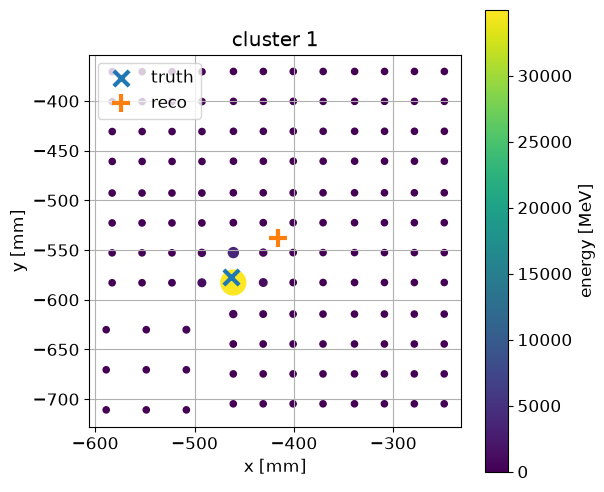

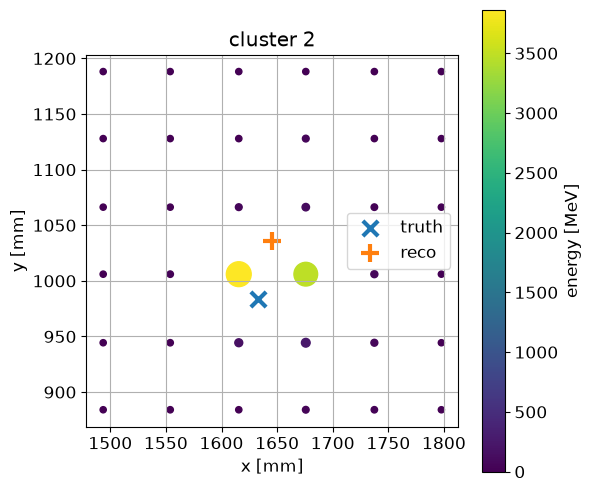

In [16]:
def plot_cluster(i):
    c = get_cluster_cells(i)
    x, y, e = c["cell_x"], c["cell_y"], c["energy"]
    sizes = 20 + 300 * e / np.nanmax(e) if np.any(e > 0) else np.full_like(e, 20)
    plt.figure(figsize=(6, 6))
    sc = plt.scatter(x, y, s=sizes, c=e)
    plt.colorbar(sc, label="energy [MeV]")
    plt.scatter(scalar("sig_flux_entry_x")[i], scalar("sig_flux_entry_y")[i], marker="x", s=120, linewidths=3, label="truth")
    plt.scatter(scalar("x_cluster")[i], scalar("y_cluster")[i], marker="+", s=160, linewidths=3, label="reco")
    plt.xlabel("x [mm]")
    plt.ylabel("y [mm]")
    plt.title(f"cluster {i}")
    plt.legend()
    plt.gca().set_aspect("equal", adjustable="box")
    plt.show()

for i in range(min(3, n_clusters)):
    plot_cluster(i)

## 11. Prototype seed

In [17]:
def find_seed(i):
    c = get_cluster_cells(i)
    e = c["energy"]
    if len(e) == 0:
        return None
    j = int(np.nanargmax(e))
    return {"index": j, "x": float(c["cell_x"][j]), "y": float(c["cell_y"][j]), "energy": float(e[j])}

find_seed(0)

{'index': 0,
 'x': -1401.8499755859375,
 'y': -2498.949951171875,
 'energy': 20528.38720703125}

## 12. Seed-to-truth distance

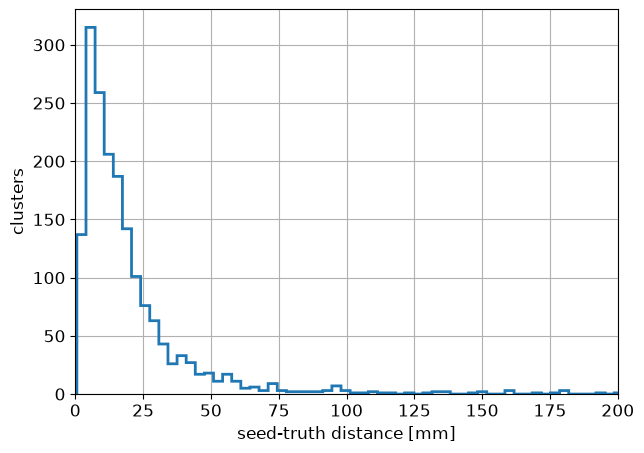

median seed-truth: 13.75 mm


In [18]:
xt = scalar("sig_flux_entry_x")
yt = scalar("sig_flux_entry_y")
seed_dr = []
for i in range(n_clusters):
    s = find_seed(i)
    seed_dr.append(np.hypot(s["x"] - xt[i], s["y"] - yt[i]) if s else np.nan)
seed_dr = np.asarray(seed_dr)
plt.figure()
plt.hist(seed_dr, bins=2000, histtype="step", linewidth=2)
plt.xlim(0, 200)
plt.xlabel("seed-truth distance [mm]")
plt.ylabel("clusters")
plt.show()
print("median seed-truth:", round(float(np.nanmedian(seed_dr)), 2), "mm")

## 13. Seed near truth efficiency

In [19]:
for radius in [10, 25, 50, 100]:
    found = 0
    dists = []
    for i in range(n_clusters):
        c = get_cluster_cells(i)
        d = np.hypot(c["cell_x"] - xt[i], c["cell_y"] - yt[i])
        sel = d < radius
        if np.any(sel):
            found += 1
            dists.append(float(np.nanmin(d[sel])))
    print(f"radius {radius:5.1f} mm | eff {found / n_clusters:6.2%} | median {np.nanmedian(dists):7.2f}")

radius  10.0 mm | eff 43.10% | median    6.27


radius  25.0 mm | eff 89.00% | median   10.57


radius  50.0 mm | eff 97.65% | median   11.57


radius 100.0 mm | eff 98.77% | median   11.61


## Dataset utilities

In [20]:
_PITCH = np.array([15.0, 30.0, 40.0, 60.0, 120.0])

def derive_geom(c):
    x = c["cell_x"]
    y = c["cell_y"]
    ix = c["imodx"]
    iy = c["jmody"]
    pts = np.stack([x, y], 1)
    pitch = np.full(len(x), np.nan)
    for key in {(int(a), int(b)) for a, b in zip(ix, iy)}:
        sel = (ix == key[0]) & (iy == key[1])
        p = pts[sel]
        if len(p) >= 2:
            d = np.sqrt(((p[:, None, :] - p[None, :, :]) ** 2).sum(-1))
            d[d == 0] = np.inf
            pitch[sel] = np.median(np.min(d, axis=1))
    fill = np.nanmedian(pitch) if np.isfinite(pitch).any() else 120.0
    pitch[~np.isfinite(pitch)] = fill
    seed = int(np.nanargmax(c["energy"]))
    rel_x = x - x[seed]
    rel_y = y - y[seed]
    rel_dr = np.hypot(rel_x, rel_y)
    mod = np.array([int(np.argmin(np.abs(_PITCH - p))) for p in pitch], dtype=float)
    return pitch, mod, rel_x, rel_y, rel_dr, seed

def build_features(c, variant):
    x = c["cell_x"]
    y = c["cell_y"]
    e = c["energy"]
    fr = c["cell_energies_front"]
    bk = c["cell_energies_back"]
    pitch, mod, rel_x, rel_y, rel_dr, seed = derive_geom(c)
    if variant == "energy":
        return np.stack([e], 1)
    if variant == "energy_pos":
        return np.stack([e, x, y], 1)
    if variant == "energy_pos_geom":
        return np.stack([e, x, y, pitch, mod], 1)
    if variant == "energy_pos_split":
        return np.stack([fr, bk, x, y], 1)
    if variant == "abs":
        return np.stack([e, x, y], 1)
    if variant == "rel":
        return np.stack([e, rel_x, rel_y, rel_dr], 1)
    raise ValueError(variant)

## Create PyTorch dataset

In [ ]:
class PicoCalDataset(Dataset):
    def __init__(self, path, variant="energy_pos_geom", target="gev"):
        with uproot.open(path) as f:
            self.a = f[TREE_NAME].arrays(
                ["cell_x", "cell_y", "cell_energies_front", "cell_energies_back", "energy",
                 "cell_times_front", "cell_times_back", "imodx", "jmody", "sig_flux_eTot"],
                library="ak")
        self.variant = variant
        self.target = target

    def __len__(self):
        return len(self.a)

    def __getitem__(self, i):
        c = {k: np.asarray(ak.to_numpy(self.a[k][i])).astype(float) for k in
             ["cell_x", "cell_y", "cell_energies_front", "cell_energies_back", "energy",
              "cell_times_front", "cell_times_back", "imodx", "jmody"]}
        feats = build_features(c, self.variant)
        y = float(self.a["sig_flux_eTot"][i])
        if self.target == "log":
            y = float(np.log(max(y, 1e-3)))
        return torch.tensor(feats, dtype=torch.float32), torch.tensor([y], dtype=torch.float32)

ds = PicoCalDataset(INPUT_FILE)
feat, target = ds[0]
print("features:", tuple(feat.shape), "target:", round(target.item(), 3), "GeV")
print("on device:", feat.to(DEVICE).device)

features: (9, 5) target: 22.652 GeV
on device: cpu


## Exercise 2 — padding mask

In [22]:
def collate(batch):
    feats, ys = zip(*batch)
    lengths = [f.shape[0] for f in feats]
    Lmax = max(lengths)
    F = feats[0].shape[1]
    B = len(batch)
    X = torch.zeros(B, Lmax, F)
    mask = torch.zeros(B, Lmax, dtype=torch.bool)
    for i, f in enumerate(feats):
        X[i, : f.shape[0]] = f
        mask[i, : f.shape[0]] = True
    return X.to(DEVICE), mask.to(DEVICE), torch.stack(ys).to(DEVICE)

loader = DataLoader(ds, batch_size=8, shuffle=False, collate_fn=collate)
X, mask, Y = next(iter(loader))
print("X:", tuple(X.shape), "mask:", tuple(mask.shape), "Y:", tuple(Y.shape))
print("real cells per row:", mask.sum(1).tolist())

X: (8, 137, 5) mask: (8, 137) Y: (8, 1)
real cells per row: [9, 137, 36, 9, 9, 9, 21, 84]


## Exercise 3 — compare token feature sets

In [23]:
for v in ["energy", "energy_pos", "energy_pos_geom", "energy_pos_split"]:
    d = PicoCalDataset(INPUT_FILE, variant=v)
    f0, _ = d[0]
    print(f"{v:18s} F = {f0.shape[1]}")

energy             F = 1
energy_pos         F = 3
energy_pos_geom    F = 5


energy_pos_split   F = 4


## Exercise 4 — relative vs absolute coordinates

In [24]:
for v in ["abs", "rel"]:
    d = PicoCalDataset(INPUT_FILE, variant=v)
    f0, _ = d[0]
    print(f"{v:4s} F = {f0.shape[1]}")

c0 = {k: np.asarray(ak.to_numpy(ds.a[k][0])).astype(float) for k in
      ["cell_x", "cell_y", "energy", "imodx", "jmody", "cell_energies_front", "cell_energies_back"]}
_, _, rx, ry, rdr, seed = derive_geom(c0)
print("seed rel coords:", round(float(rx[seed]), 3), round(float(ry[seed]), 3), round(float(rdr[seed]), 3))

abs  F = 3


rel  F = 4
seed rel coords: 0.0 0.0 0.0


# Feature significance and target distribution

Two things the model design depends on, asked directly of the data:
1. Is the target (true photon energy) **uniform, normal, or steeply falling**? (A flat/uniform spectrum vs a falling one changes how we read resolution and what loss makes sense.)
2. Which cluster-level features actually **carry information** about the target — via correlation and a BDT's permutation importance.

In [1]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path

repo = Path.cwd().resolve()
if repo.name == "notebooks":
    repo = repo.parent
sys.path.insert(0, str(repo / "scripts"))
from run_experiments import build

files = sorted((repo / "data" / "full").glob("matched_*.root"))[:30]
D = build(files, 3, 100.0)
FEAT = ["log_sumE", "front_back_ratio", "n_cells", "log_seedE", "lateral_rms", "region"]
X = np.array(D["agg"]); yln = np.array(D["y"]); Et = np.array(D["Etrue"])
df = pd.DataFrame(X, columns=FEAT); df["log_Etrue"] = yln
{"clusters": len(df), "files": len(files), "features": FEAT}

{'clusters': 10930,
 'files': 30,
 'features': ['log_sumE',
  'front_back_ratio',
  'n_cells',
  'log_seedE',
  'lateral_rms',
  'region']}

## Target distribution — uniform, normal, or falling?

If it is steeply falling (many low-energy, few high-energy) the model sees mostly low-E showers; if it is flat/uniform the range is covered evenly. Skew ~0 with a bell = normal; skew > 0 = falling tail.

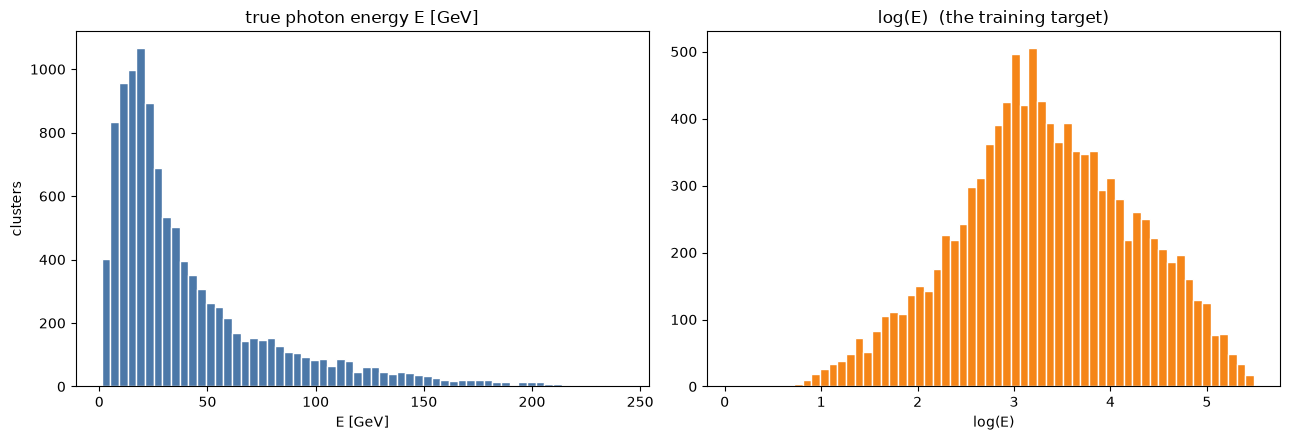

{'E_min': 1.1,
 'E_median': 26.9,
 'E_max': 241.8,
 'E_skew': 1.84,
 'logE_skew': -0.09}

In [2]:
import matplotlib.pyplot as plt
from scipy.stats import skew

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].hist(Et, bins=60, color="#4c78a8", edgecolor="white")
ax[0].set_title("true photon energy E [GeV]"); ax[0].set_xlabel("E [GeV]"); ax[0].set_ylabel("clusters")
ax[1].hist(yln, bins=60, color="#f58518", edgecolor="white")
ax[1].set_title("log(E)  (the training target)"); ax[1].set_xlabel("log(E)")
plt.tight_layout(); plt.show()

{"E_min": round(float(Et.min()), 1), "E_median": round(float(np.median(Et)), 1),
 "E_max": round(float(Et.max()), 1), "E_skew": round(float(skew(Et)), 2),
 "logE_skew": round(float(skew(yln)), 2)}

## Which features carry signal

Left: absolute Pearson correlation of each feature with `log(E)`. Right: a BDT's permutation importance (how much R^2 drops when that feature is shuffled). A feature that is flat on both is not helping the prediction.

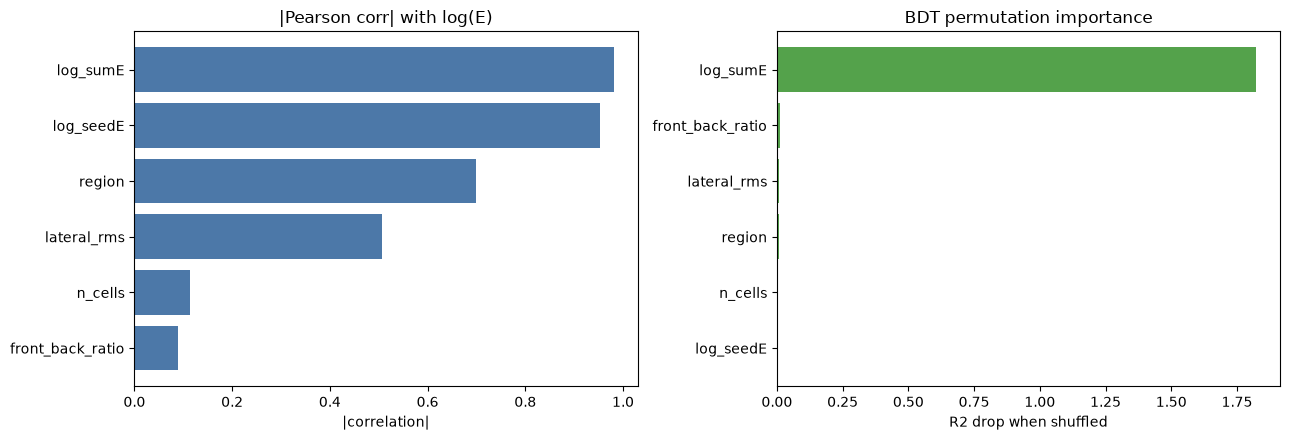

,abs_corr,bdt_importance
log_sumE,0.981,1.8224
front_back_ratio,0.090,0.0123
lateral_rms,0.507,0.0090
region,0.700,0.0062
n_cells,0.114,0.0016
log_seedE,0.952,0.0014


In [3]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

corr = df[FEAT].corrwith(df["log_Etrue"]).abs().sort_values()
Xtr, Xte, ytr, yte = train_test_split(X, yln, test_size=0.3, random_state=0)
gb = HistGradientBoostingRegressor(max_iter=300, random_state=0).fit(Xtr, ytr)
imp = permutation_importance(gb, Xte, yte, n_repeats=10, random_state=0)
impser = pd.Series(imp.importances_mean, index=FEAT).sort_values()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].barh(corr.index, corr.values, color="#4c78a8")
ax[0].set_title("|Pearson corr| with log(E)"); ax[0].set_xlabel("|correlation|")
ax[1].barh(impser.index, impser.values, color="#54a24b")
ax[1].set_title("BDT permutation importance"); ax[1].set_xlabel("R2 drop when shuffled")
plt.tight_layout(); plt.show()

pd.DataFrame({"abs_corr": df[FEAT].corrwith(df["log_Etrue"]).abs().round(3),
              "bdt_importance": pd.Series(imp.importances_mean, index=FEAT).round(4)}).sort_values("bdt_importance", ascending=False)

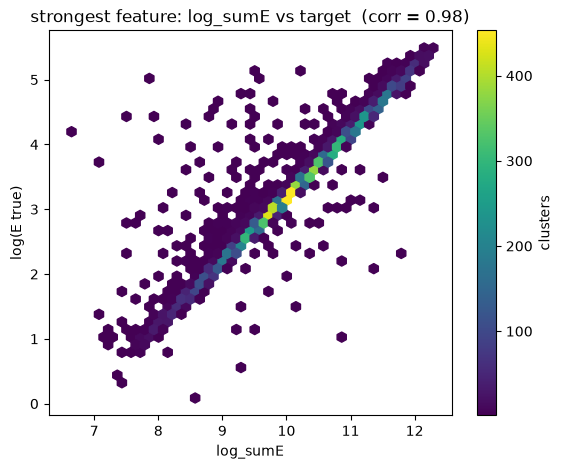

In [4]:
top = corr.index[-1]
plt.figure(figsize=(6.5, 5))
hb = plt.hexbin(df[top], df["log_Etrue"], gridsize=40, cmap="viridis", mincnt=1)
plt.xlabel(top); plt.ylabel("log(E true)")
plt.title(f"strongest feature: {top} vs target  (corr = {df[top].corr(df['log_Etrue']):.2f})")
plt.colorbar(hb, label="clusters"); plt.show()

## Takeaway

The features that dominate correlation and BDT importance are the ones the model genuinely relies on; features flat on both are candidates to drop (matching the E12 ablations in notebook 05). The target's shape (above) tells us whether resolution should be read per energy bin. If most information sits in one or two features, a simple model competes with the transformer — which is what we observe, and the reason to look for the transformer's edge in relational / timing structure.

# Transformer-ready dataset

## Transformer-ready — feature layout

In [25]:
CONT_DIM = 9
THRESH_TIME = 1e6

def raw_token_features(c):
    e = c["energy"]
    fr = c["cell_energies_front"]
    bk = c["cell_energies_back"]
    tf = c["cell_times_front"]
    tb = c["cell_times_back"]
    pitch, mod, rel_x, rel_y, rel_dr, seed = derive_geom(c)
    vf = np.abs(tf) < THRESH_TIME
    vb = np.abs(tb) < THRESH_TIME
    tf = np.where(vf, tf, 0.0)
    tb = np.where(vb, tb, 0.0)
    time_valid = (vf & vb).astype(float)
    cont = np.stack([
        np.log1p(np.clip(e, 0, None)),
        np.log1p(np.clip(fr, 0, None)),
        np.log1p(np.clip(bk, 0, None)),
        rel_x / pitch,
        rel_y / pitch,
        rel_dr / pitch,
        tf,
        tb,
        np.log(pitch),
    ], 1)
    onehot = np.zeros((len(e), len(_PITCH)))
    onehot[np.arange(len(e)), mod.astype(int)] = 1.0
    flags = np.concatenate([onehot, time_valid[:, None]], 1)
    return cont, flags

## Transformer-ready — dataset with normalization

In [26]:
class ShowerTokenDataset(Dataset):
    def __init__(self, path):
        with uproot.open(path) as f:
            self.a = f[TREE_NAME].arrays(
                ["cell_x", "cell_y", "cell_energies_front", "cell_energies_back", "energy",
                 "cell_times_front", "cell_times_back", "imodx", "jmody", "sig_flux_eTot"],
                library="ak")
        self.mean = None
        self.std = None

    def __len__(self):
        return len(self.a)

    def _cells(self, i):
        return {k: np.asarray(ak.to_numpy(self.a[k][i])).astype(float) for k in
                ["cell_x", "cell_y", "cell_energies_front", "cell_energies_back", "energy",
                 "cell_times_front", "cell_times_back", "imodx", "jmody"]}

    def fit_norm(self, n_sample=400):
        chunks = [raw_token_features(self._cells(i))[0] for i in range(min(n_sample, len(self)))]
        allc = np.concatenate(chunks, 0)
        self.mean = allc.mean(0)
        self.std = allc.std(0) + 1e-6
        return self

    def __getitem__(self, i):
        c = self._cells(i)
        cont, onehot = raw_token_features(c)
        if self.mean is not None:
            cont = (cont - self.mean) / self.std
        feats = np.concatenate([cont, onehot], 1)
        y = float(np.log(max(float(self.a["sig_flux_eTot"][i]), 1e-3)))
        return torch.tensor(feats, dtype=torch.float32), torch.tensor([y], dtype=torch.float32)

tds = ShowerTokenDataset(INPUT_FILE).fit_norm()
f0, y0 = tds[0]
print("token feature dim F =", f0.shape[1], "| target logE =", round(y0.item(), 3))
print("continuous-block per-sample mean:", np.round(f0[:, :CONT_DIM].mean(0).numpy(), 2))

token feature dim F = 15 | target logE = 3.12
continuous-block per-sample mean: [ 2.1   1.52  2.25 -0.12 -0.03 -1.54  1.44  1.35  4.17]


## Transformer-ready — masked batch

In [27]:
def collate_norm(batch):
    feats, ys = zip(*batch)
    Lmax = max(f.shape[0] for f in feats)
    F = feats[0].shape[1]
    B = len(batch)
    X = torch.zeros(B, Lmax, F)
    mask = torch.zeros(B, Lmax, dtype=torch.bool)
    for i, f in enumerate(feats):
        X[i, : f.shape[0]] = f
        mask[i, : f.shape[0]] = True
    return X.to(DEVICE), mask.to(DEVICE), torch.stack(ys).to(DEVICE)

tloader = DataLoader(tds, batch_size=16, shuffle=True, collate_fn=collate_norm)
Xb, mb, Yb = next(iter(tloader))
print("X:", tuple(Xb.shape), "mask:", tuple(mb.shape), "Y:", tuple(Yb.shape))

X: (16, 384, 15) mask: (16, 384) Y: (16, 1)


## Transformer-ready — tiny set transformer

In [28]:
import torch.nn as nn

class TinyShowerTransformer(nn.Module):
    def __init__(self, in_dim, d_model=32, nhead=4, layers=2):
        super().__init__()
        self.embed = nn.Linear(in_dim, d_model)
        layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=64, batch_first=True)
        self.enc = nn.TransformerEncoder(layer, layers, enable_nested_tensor=False)
        self.head = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, x, mask):
        h = self.enc(self.embed(x), src_key_padding_mask=~mask)
        w = mask.unsqueeze(-1).float()
        pooled = (h * w).sum(1) / w.sum(1).clamp(min=1)
        return self.head(pooled)

torch.manual_seed(0)
model = TinyShowerTransformer(Xb.shape[2]).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
pred = model(Xb, mb)
loss0 = nn.functional.mse_loss(pred, Yb)
opt.zero_grad()
loss0.backward()
opt.step()
loss1 = nn.functional.mse_loss(model(Xb, mb), Yb)
print("output:", tuple(pred.shape), "| loss:", round(loss0.item(), 4), "-> after 1 step:", round(loss1.item(), 4))

output: (16, 1) | loss: 4.7268 -> after 1 step: 4.4332


## Transformer-ready — summary

In [29]:
print({
    "token_dim_F": int(Xb.shape[2]),
    "continuous_normalized": CONT_DIM,
    "onehot_modtype": len(_PITCH),
    "time_valid_flag": 1,
    "features": "logE, log front/back, rel_x/p, rel_y/p, rel_dr/p, t_front(clean), t_back(clean), log pitch, onehot modtype, time_valid",
    "target": "log(sig_flux_eTot) single photon",
    "pooling": "masked mean",
    "device": str(DEVICE),
})
print("time-col norm stats: mean", np.round(tds.mean[6:8], 3), "std", np.round(tds.std[6:8], 3))

{'token_dim_F': 15, 'continuous_normalized': 9, 'onehot_modtype': 5, 'time_valid_flag': 1, 'features': 'logE, log front/back, rel_x/p, rel_y/p, rel_dr/p, t_front(clean), t_back(clean), log pitch, onehot modtype, time_valid', 'target': 'log(sig_flux_eTot) single photon', 'pooling': 'masked mean', 'device': 'cpu'}
time-col norm stats: mean [22.81  31.624] std [38.712 42.273]
